# 🧠 Parkinson's Disease Prediction — Deep Learning (ANN)

This notebook replaces the previous classical ML models (Logistic Regression, Random Forest, SVM)
with an **Artificial Neural Network (ANN)** built in TensorFlow/Keras.

**Dataset features used (same as the Flask app — 22 voice-measurement features):**

| Group | Features |
|-------|----------|
| Fundamental frequency | MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz) |
| Jitter (pitch variation) | MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP |
| Shimmer (amplitude variation) | MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA |
| Noise ratios | NHR, HNR |
| Nonlinear dynamics | RPDE, DFA, spread1, spread2, D2, PPE |

**Target:** `status` (1 = Parkinson's positive, 0 = Healthy)

## Step 1 — Import Libraries

In [2]:
# Standard data-science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)

# TensorFlow / Keras — Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility seed
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


## Step 2 — Load & Explore the Dataset

In [3]:
# Load the CSV (place parkinson.csv in the same folder as this notebook)
df = pd.read_csv('parkinson.csv')

print('Shape:', df.shape)
df.head()

Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [4]:
# Basic info: data types, null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

Target distribution (status):
status
1    147
0     48
Name: count, dtype: int64


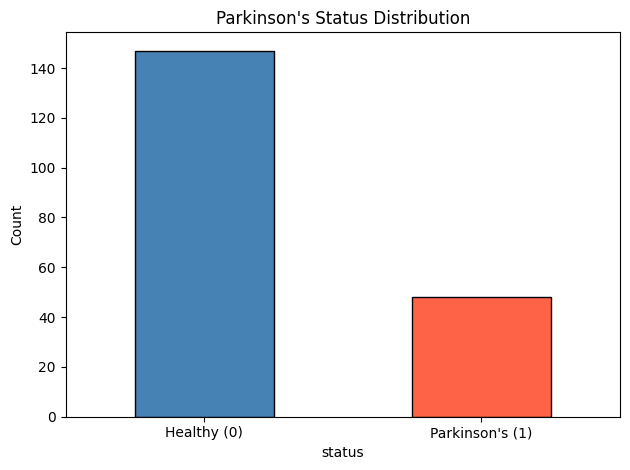

In [5]:
# Class distribution
print('Target distribution (status):')
print(df['status'].value_counts())

df['status'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title("Parkinson's Status Distribution")
plt.xticks([0,1], ['Healthy (0)', "Parkinson's (1)"], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

In [6]:
# --- 3a. Handle missing values ---
print('Missing values per column:')
print(df.isnull().sum())

# Fill any numeric NaNs with the column median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

print('\nMissing values after fill:', df.isnull().sum().sum())

Missing values per column:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

Missing values after fill: 0


In [7]:
# --- 3b. Define features (same order as Flask app) ---
FEATURES = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)',
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA',
    'NHR', 'HNR',
    'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE'
]
TARGET = 'status'

# Drop non-feature columns (name is a string identifier)
X_df = df[FEATURES]
y    = df[TARGET].values

print(f'Feature count: {len(FEATURES)}')
X_df.describe()

Feature count: 22


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.024081,0.046993,0.024847,21.885974,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.016947,0.030459,0.040418,4.425764,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.007190,0.013640,0.000650,8.441000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.013080,0.024735,0.005925,19.198000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.018260,0.038360,0.011660,22.085000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.029400,0.060795,0.025640,25.075500,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.137780,0.169420,0.314820,33.047000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


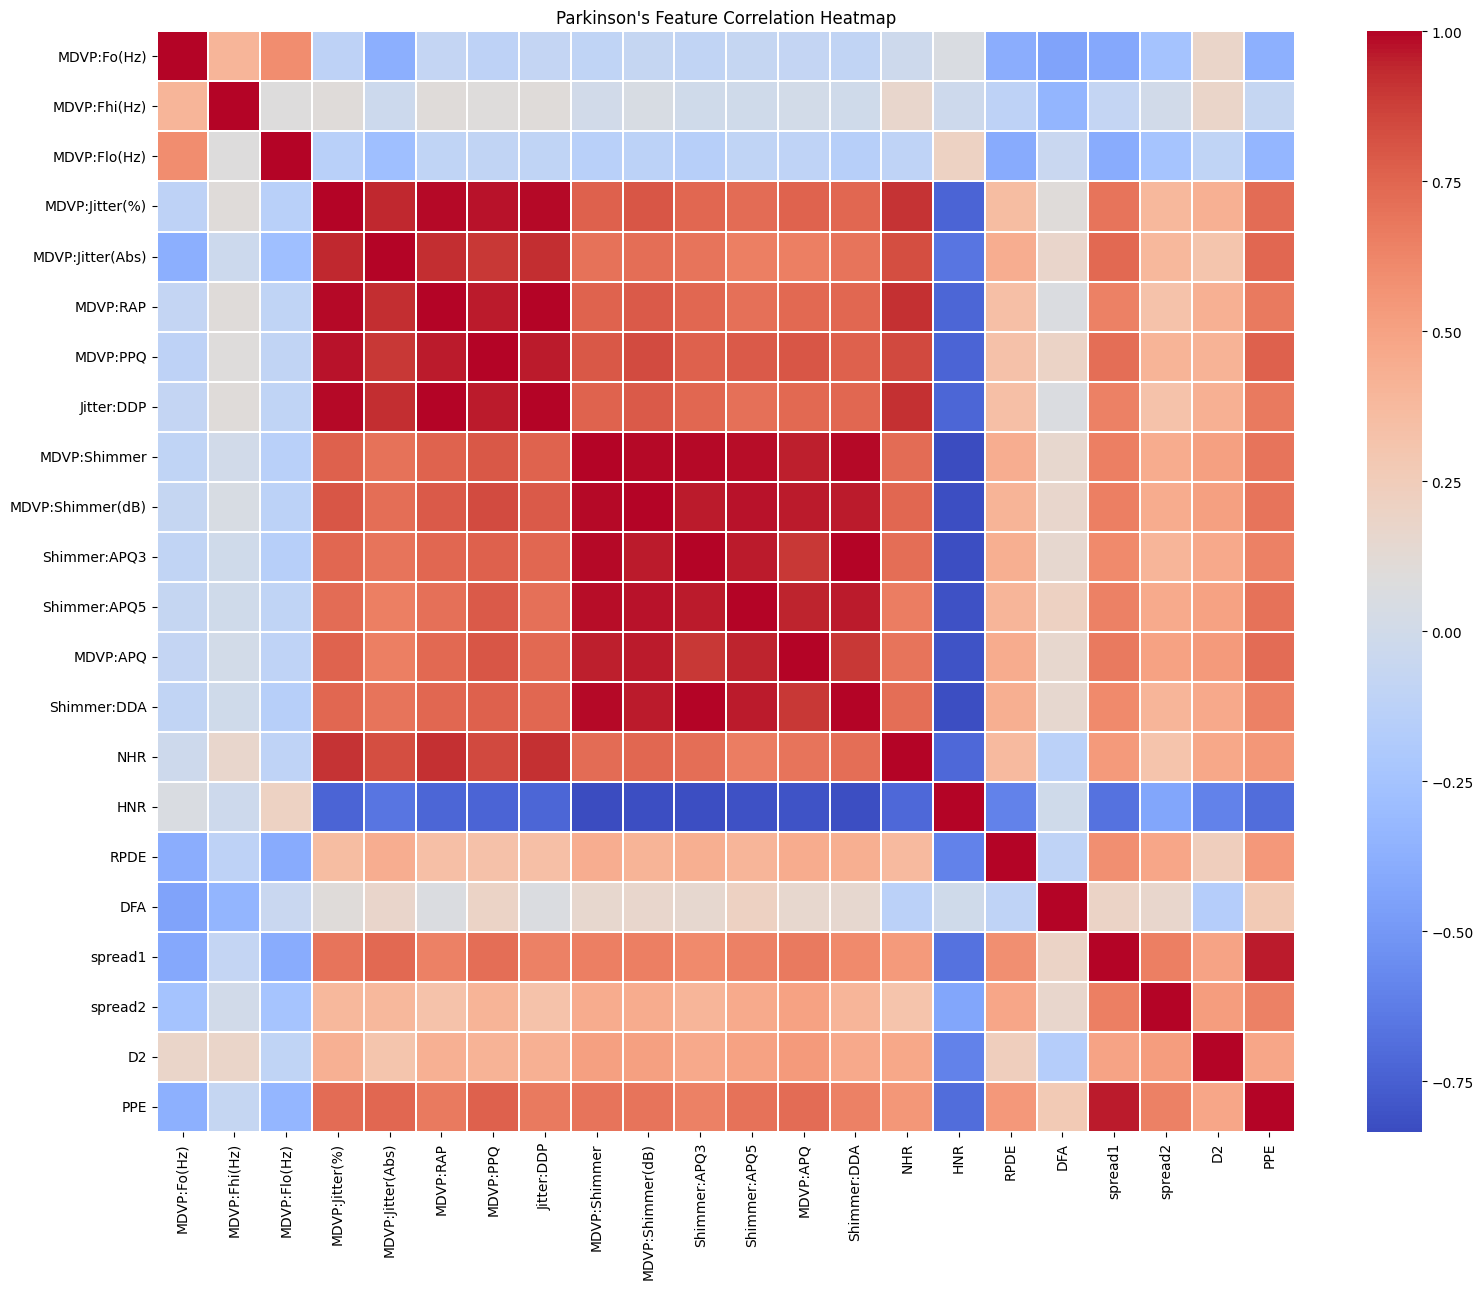

In [8]:
# --- 3c. Correlation heatmap ---
plt.figure(figsize=(16, 13))
sns.heatmap(X_df.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title("Parkinson's Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [9]:
# --- 3d. Train / Val / Test split ---
X = X_df.values

# Note: Parkinson dataset is small (~195 rows), so we use 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (136, 22)  Val: (29, 22)  Test: (30, 22)


In [10]:
# --- 3e. Feature scaling ---
# Voice measurements span very different ranges; scaling is critical here.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('Scaling complete. Sample mean (should be ~0):', X_train.mean(axis=0).round(2))

Scaling complete. Sample mean (should be ~0): [-0. -0. -0.  0.  0.  0.  0. -0. -0.  0. -0.  0. -0. -0.  0. -0. -0. -0.
  0. -0. -0.  0.]


## Step 4 — Build the ANN Model

Because the Parkinson dataset is **small and high-dimensional (22 features, ~195 rows)**,
we use a moderately sized network with strong regularisation to prevent overfitting.

Architecture:
```
Input (22)  →  Dense(128, ReLU)  →  Dropout(0.4)
            →  Dense(64,  ReLU)  →  Dropout(0.3)
            →  Dense(32,  ReLU)  →  Dropout(0.2)
            →  Dense(16,  ReLU)
            →  Output Dense(1, Sigmoid)
```

In [11]:
def build_model(input_dim: int) -> keras.Model:
    """Build and compile an ANN for Parkinson's binary classification."""
    model = keras.Sequential([
        # --- Input ---
        layers.Input(shape=(input_dim,)),

        # --- Hidden layer 1: 128 neurons ---
        layers.Dense(128, activation='relu', kernel_initializer='he_normal',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),  # high dropout because dataset is small

        # --- Hidden layer 2: 64 neurons ---
        layers.Dense(64, activation='relu', kernel_initializer='he_normal',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # --- Hidden layer 3: 32 neurons ---
        layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # --- Hidden layer 4: 16 neurons ---
        layers.Dense(16, activation='relu', kernel_initializer='he_normal'),

        # --- Output: sigmoid → probability of Parkinson's ---
        layers.Dense(1, activation='sigmoid')
    ], name='parkinson_ann')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "parkinson_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 448 (1.75 KB)

## Step 5 — Train the Model

In [12]:
# EarlyStopping — stop when val_loss plateaus and restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau — lower learning rate when progress stalls
# (especially helpful for small datasets)
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,         # smaller batch suits the small dataset
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.4412 - loss: 1.0188 - val_accuracy: 0.3103 - val_loss: 0.9374 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4926 - loss: 0.9207 - val_accuracy: 0.4138 - val_loss: 0.8334 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5882 - loss: 0.7847 - val_accuracy: 0.5517 - val_loss: 0.7472 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7206 - loss: 0.6360 - val_accuracy: 0.7241 - val_loss: 0.6785 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6397 - loss: 0.6760 - val_accuracy: 0.7586 - val_loss: 0.6274 - learning_rate: 0.0010
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6765 - loss: 0.6606 - val_accuracy: 0.7586 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7426 - loss: 0.5833 - val_accuracy: 

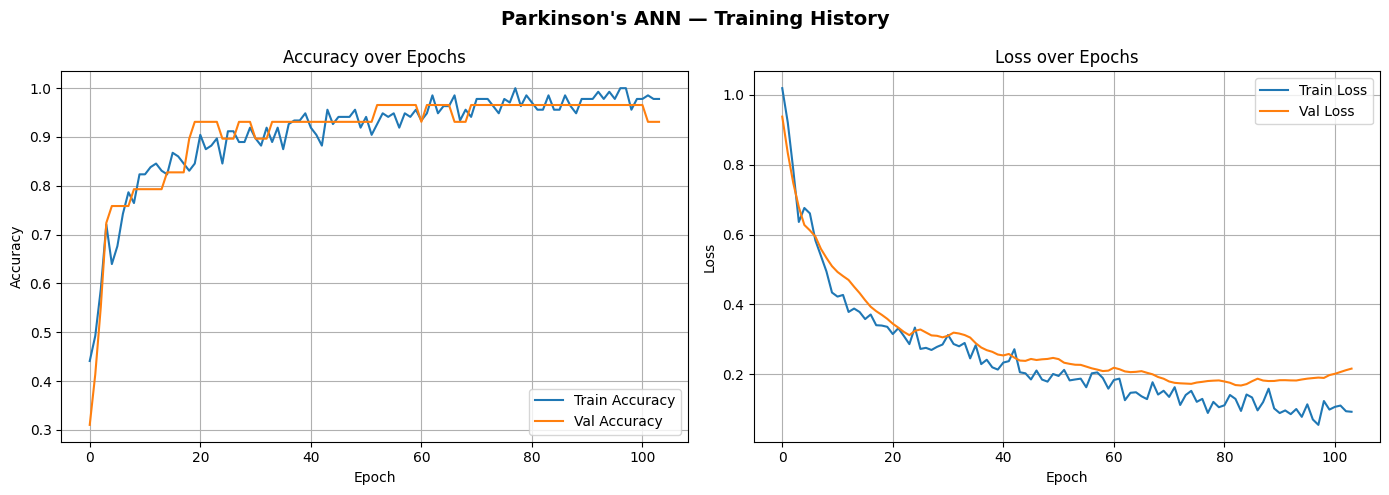

In [13]:
# --- Plot training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Parkinson's ANN — Training History", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Evaluate on Test Set

In [14]:
# Predict probabilities, threshold at 0.5
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"ROC-AUC Score : {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Parkinson's"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Test Accuracy : 0.8333  (83.33%)
ROC-AUC Score : 0.9261

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.80      0.50      0.62         8
 Parkinson's       0.84      0.95      0.89        22

    accuracy                           0.83        30
   macro avg       0.82      0.73      0.75        30
weighted avg       0.83      0.83      0.82        30



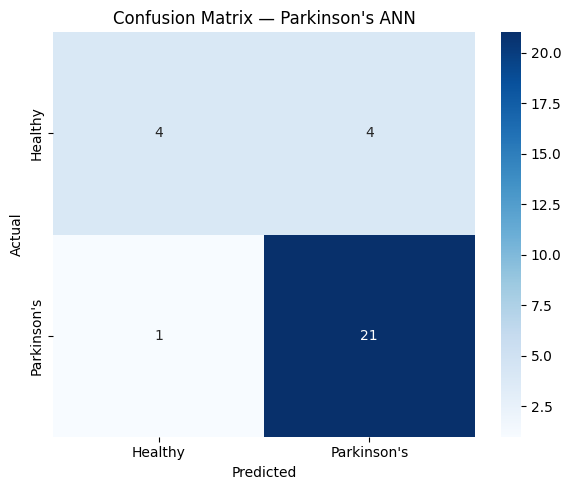

In [15]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Parkinson's"],
            yticklabels=["Healthy", "Parkinson's"])
plt.title("Confusion Matrix — Parkinson's ANN")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 7 — Save the Model & Scaler

In [16]:
import pickle

# Save Keras model
model.save('parkinson_ann_model.h5')
print('Model saved → parkinson_ann_model.h5')

# Save scaler
with open('parkinson_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved → parkinson_scaler.pkl')

Model saved → parkinson_ann_model.h5
Scaler saved → parkinson_scaler.pkl


## Step 8 — Final Prediction Function

This function accepts the same 22 parameters that the Flask `/parkinson` route collects from the form.

In [17]:
def predict_parkinson(
    mdvp_fo: float,          # MDVP:Fo(Hz)
    mdvp_fhi: float,         # MDVP:Fhi(Hz)
    mdvp_flo: float,         # MDVP:Flo(Hz)
    mdvp_jitter_pct: float,  # MDVP:Jitter(%)
    mdvp_jitter_abs: float,  # MDVP:Jitter(Abs)
    mdvp_rap: float,
    mdvp_ppq: float,
    jitter_ddp: float,
    mdvp_shimmer: float,
    mdvp_shimmer_db: float,
    shimmer_apq3: float,
    shimmer_apq5: float,
    mdvp_apq: float,
    shimmer_dda: float,
    nhr: float,
    hnr: float,
    rpde: float,
    dfa: float,
    spread1: float,
    spread2: float,
    d2: float,
    ppe: float
) -> str:
    """
    Predicts whether a patient has Parkinson's disease.

    Accepts the exact 22 voice-measurement features used by the Flask app.

    Returns
    -------
    str : 'Positive' (Parkinson's detected) or 'Negative' (Healthy)
    """
    # Build input array in the same column order used during training
    raw_input = np.array([[
        mdvp_fo, mdvp_fhi, mdvp_flo,
        mdvp_jitter_pct, mdvp_jitter_abs, mdvp_rap, mdvp_ppq, jitter_ddp,
        mdvp_shimmer, mdvp_shimmer_db, shimmer_apq3, shimmer_apq5,
        mdvp_apq, shimmer_dda,
        nhr, hnr,
        rpde, dfa, spread1, spread2, d2, ppe
    ]], dtype=float)

    # Scale using the fitted scaler
    scaled_input = scaler.transform(raw_input)

    # Predict probability
    prob  = model.predict(scaled_input, verbose=0)[0][0]
    label = 'Positive' if prob >= 0.5 else 'Negative'

    print(f"Prediction probability: {prob:.4f}  →  {label}")
    return label


# ── Demo: typical Parkinson's patient values from the dataset ──
result = predict_parkinson(
    mdvp_fo=119.992, mdvp_fhi=157.302, mdvp_flo=74.997,
    mdvp_jitter_pct=0.00784, mdvp_jitter_abs=0.00007,
    mdvp_rap=0.00370, mdvp_ppq=0.00554, jitter_ddp=0.01109,
    mdvp_shimmer=0.04374, mdvp_shimmer_db=0.42600,
    shimmer_apq3=0.02182, shimmer_apq5=0.03130,
    mdvp_apq=0.02971, shimmer_dda=0.06545,
    nhr=0.02211, hnr=21.033,
    rpde=0.414783, dfa=0.815285,
    spread1=-4.813031, spread2=0.266482,
    d2=2.301442, ppe=0.284654
)
print('Final Result:', result)

Prediction probability: 0.9996  →  Positive
Final Result: Positive


## Step 9 — How to Load Saved Model (for Flask Integration)

In your `app.py`, replace the `RandomForestClassifier` block in the `/parkinson` route with:

```python
import pickle
from tensorflow import keras

# Load once at startup (outside the route)
parkinson_model  = keras.models.load_model('parkinson_ann_model.h5')
parkinson_scaler = pickle.load(open('parkinson_scaler.pkl', 'rb'))

# Inside the /parkinson route, after collecting form inputs:
raw = np.array([[
    mdvp_fo, mdvp_fhi, mdvp_flo,
    mdvp_jitter_percent, mdvp_jitter_abs, mdvp_rap, mdvp_ppq, jitter_ddp,
    mdvp_shimmer, mdvp_shimmer_db, shimmer_apq3, shimmer_apq5,
    mdvp_apq, shimmer_dda, nhr, hnr,
    rpde, dfa, spread1, spread2, d2, ppe
]], dtype=float)

scaled = parkinson_scaler.transform(raw)
prob   = parkinson_model.predict(scaled)[0][0]
prediction_text = 'Positive' if prob >= 0.5 else 'Negative'
```